In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.ensemble import IsolationForest

In [2]:
#Data Preparation
#load dataset
df = pd.read_excel("/content/heart_disease.xlsx",sheet_name="Heart_disease")
df

,age,sex,cp,trestbps,chol,fbs,restecg,thalch,exang,oldpeak,slope,thal,num
0,63,Male,typical angina,145,233,True,lv hypertrophy,150,False,2.3,downsloping,fixed defect,0
1,41,Male,atypical angina,135,203,False,normal,132,False,0.0,flat,fixed defect,0
2,57,Male,asymptomatic,140,192,False,normal,148,False,0.4,flat,fixed defect,0
3,52,Male,typical angina,118,186,False,lv hypertrophy,190,False,0.0,flat,fixed defect,0
4,57,Male,asymptomatic,110,201,False,normal,126,True,1.5,flat,fixed defect,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
903,53,Male,asymptomatic,125,0,False,normal,120,False,1.5,upsloping,normal,4
904,62,Male,asymptomatic,166,170,False,st-t abnormality,120,True,3.0,flat,reversable defect,4
905,56,Male,non-anginal,170,0,False,lv hypertrophy,123,True,2.5,downsloping,reversable defect,4
906,56,Male,non-anginal,144,208,True,st-t abnormality,105,TURE,NaN,downsloping,reversable defect,4


In [ ]:
#Exploratory Data Analysis(EDA)

In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 908 entries, 0 to 907
Data columns (total 13 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       908 non-null    int64  
 1   sex       908 non-null    object 
 2   cp        908 non-null    object 
 3   trestbps  908 non-null    int64  
 4   chol      908 non-null    int64  
 5   fbs       908 non-null    bool   
 6   restecg   908 non-null    object 
 7   thalch    908 non-null    int64  
 8   exang     908 non-null    object 
 9   oldpeak   846 non-null    float64
 10  slope     908 non-null    object 
 11  thal      908 non-null    object 
 12  num       908 non-null    int64  
dtypes: bool(1), float64(1), int64(5), object(6)
memory usage: 86.1+ KB


In [4]:
df.describe()

,age,trestbps,chol,thalch,oldpeak,num
count,908.000000,908.000000,908.000000,908.000000,846.000000,908.000000
mean,53.791850,133.430617,201.484581,135.957048,0.891253,1.008811
std,9.158031,20.401608,112.097949,26.804929,1.093875,1.144436
min,29.000000,0.000000,0.000000,60.000000,-2.600000,0.000000
25%,47.750000,120.000000,176.750000,118.000000,0.000000,0.000000
50%,54.000000,130.000000,224.000000,138.000000,0.500000,1.000000
75%,60.000000,144.000000,270.000000,156.000000,1.500000,2.000000
max,77.000000,200.000000,603.000000,202.000000,6.200000,4.000000


In [5]:
df.dtypes

,0
age,int64
sex,object
cp,object
trestbps,int64
chol,int64
fbs,bool
restecg,object
thalch,int64
exang,object
oldpeak,float64


In [6]:
#Missing Values in Dataset
df.isnull().sum()

,0
age,0
sex,0
cp,0
trestbps,0
chol,0
fbs,0
restecg,0
thalch,0
exang,0
oldpeak,62


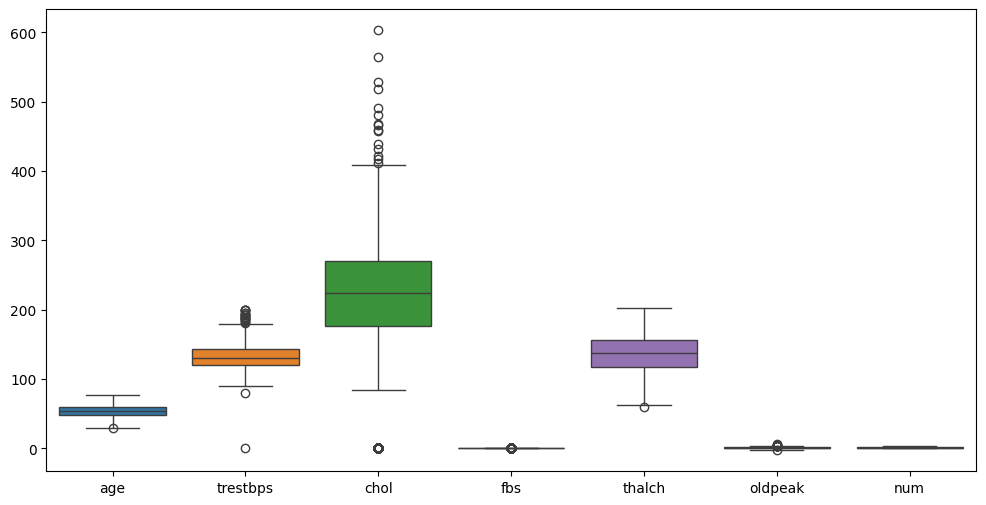

In [7]:
#Outliers detection using Box Plot
plt.figure(figsize=(12,6))
sns.boxplot(data=df)
plt.show()

In [8]:
#Outlier detection using Isolation Forest
num_col = df[["age", "trestbps", "chol", "thalch", "oldpeak"]]
iso_forest = IsolationForest(contamination=0.01, random_state=42)
outlier_predictions = iso_forest.fit_predict(num_col)

outlier_indices = num_col.index[outlier_predictions == -1]

print(f"Number of detected outliers: {len(outlier_indices)}")

Number of detected outliers: 10


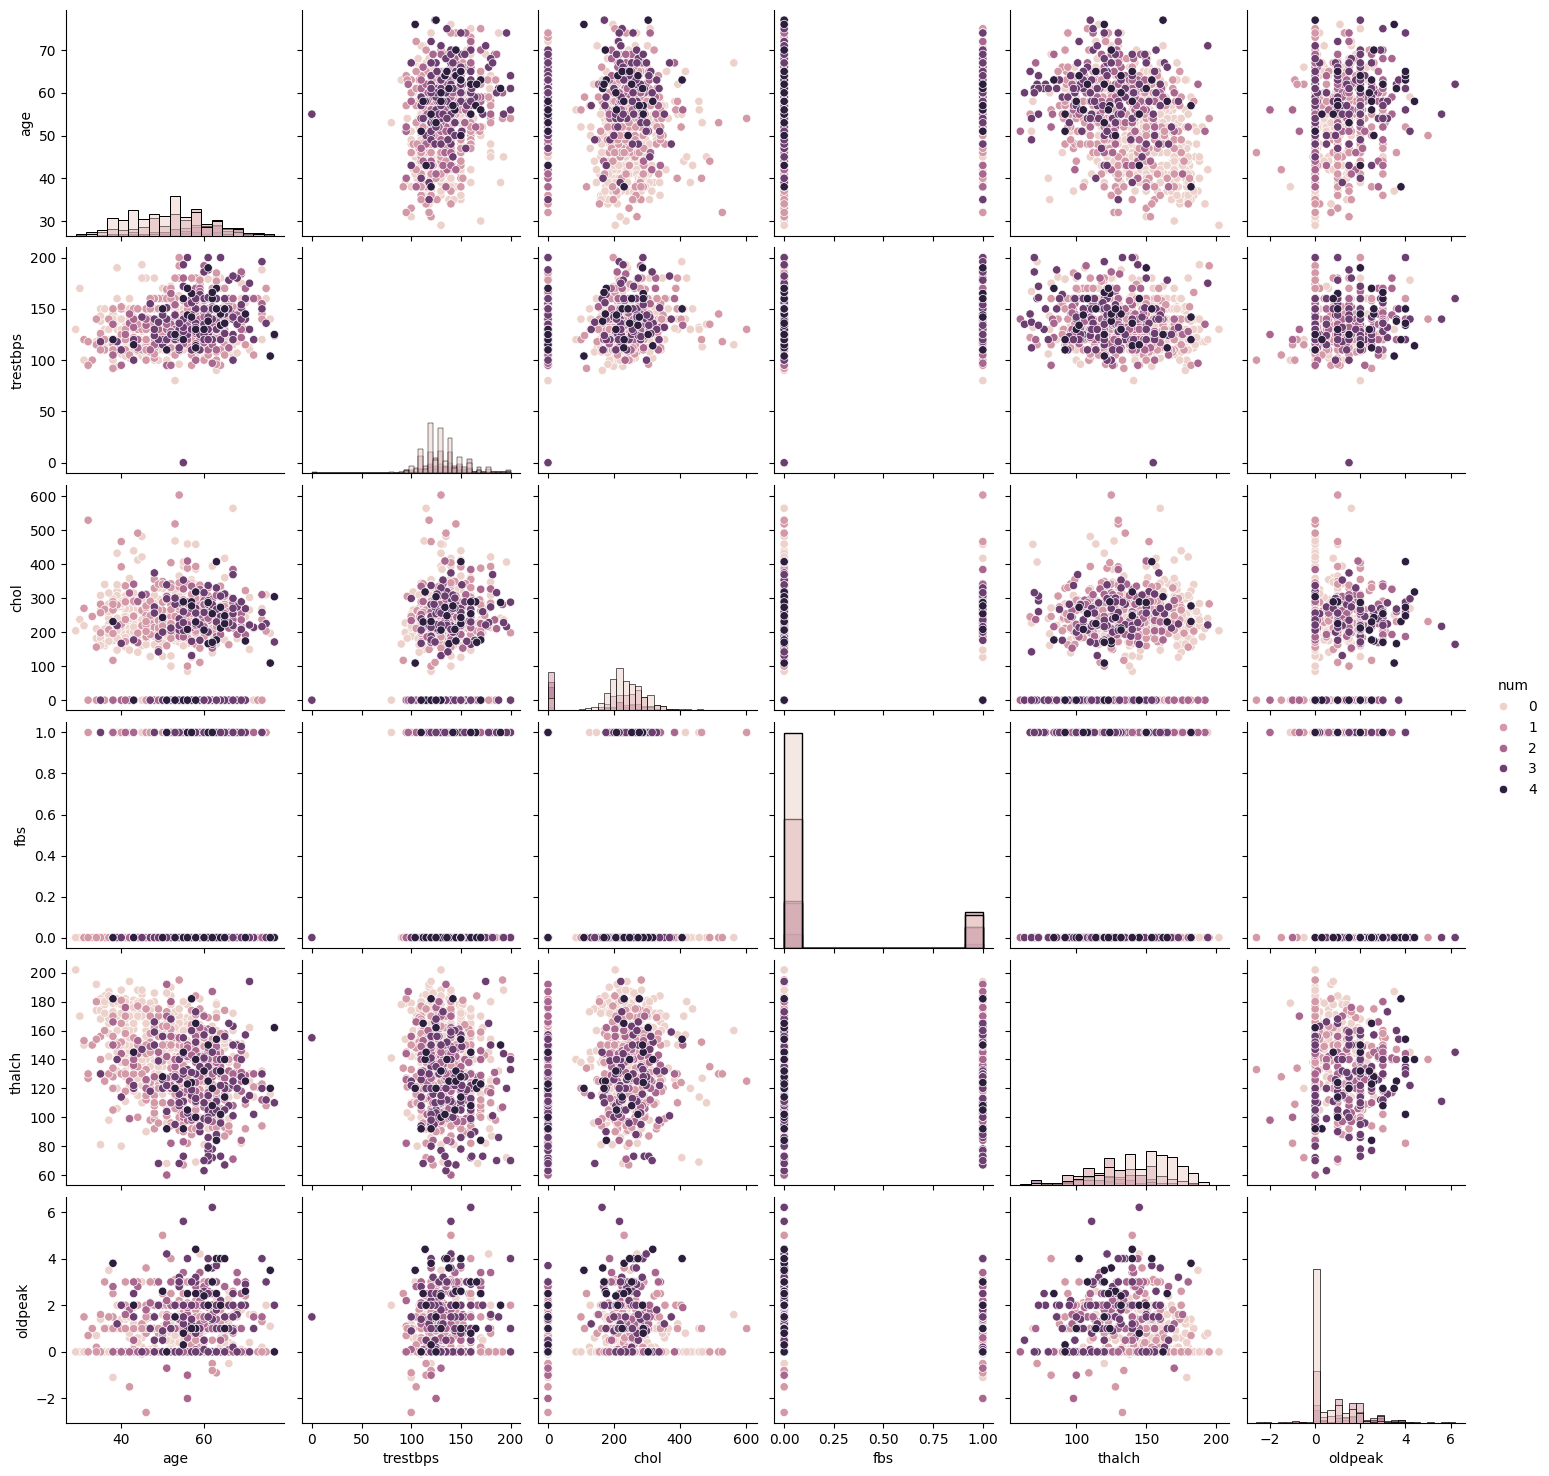

In [9]:
#Visualize the distribution of features, including histograms, box plots, and correlation matrices.
sns.pairplot(df, hue='num',diag_kind='hist')
plt.show()

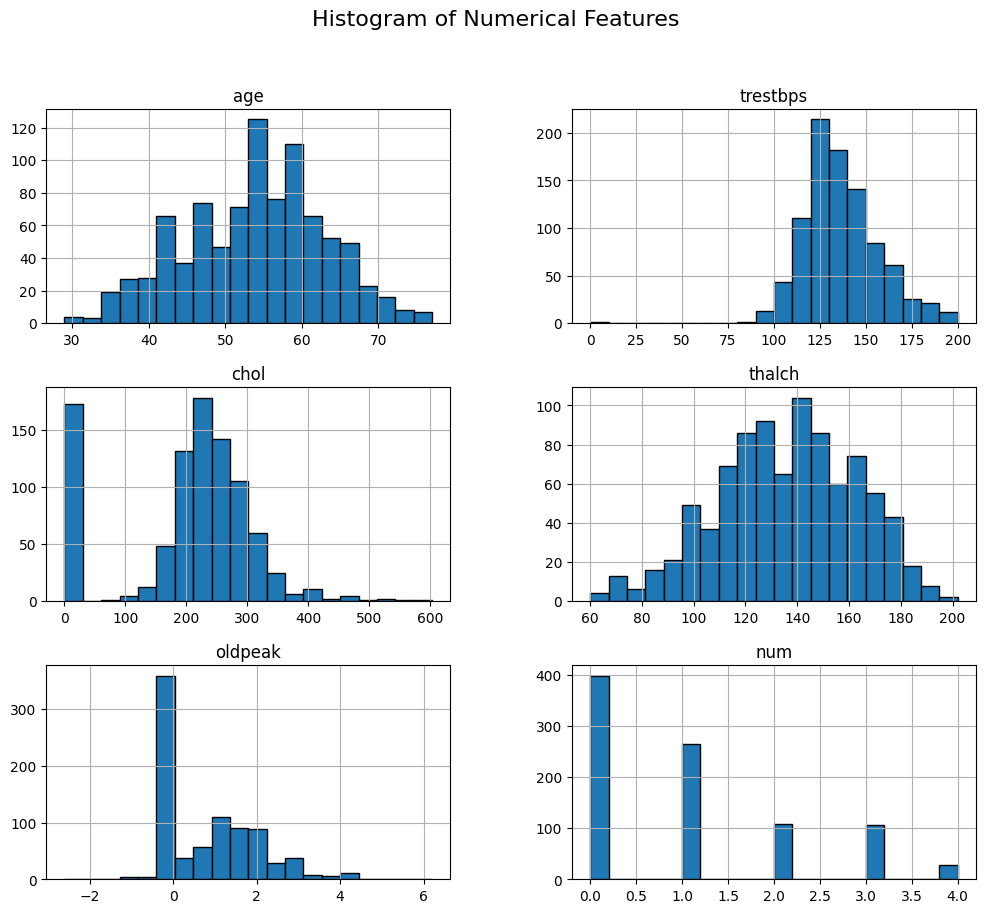

In [10]:
#Histogram for numerical features
df.hist(figsize=(12, 10), bins=20, edgecolor='black')
plt.suptitle("Histogram of Numerical Features", fontsize=16)
plt.show()

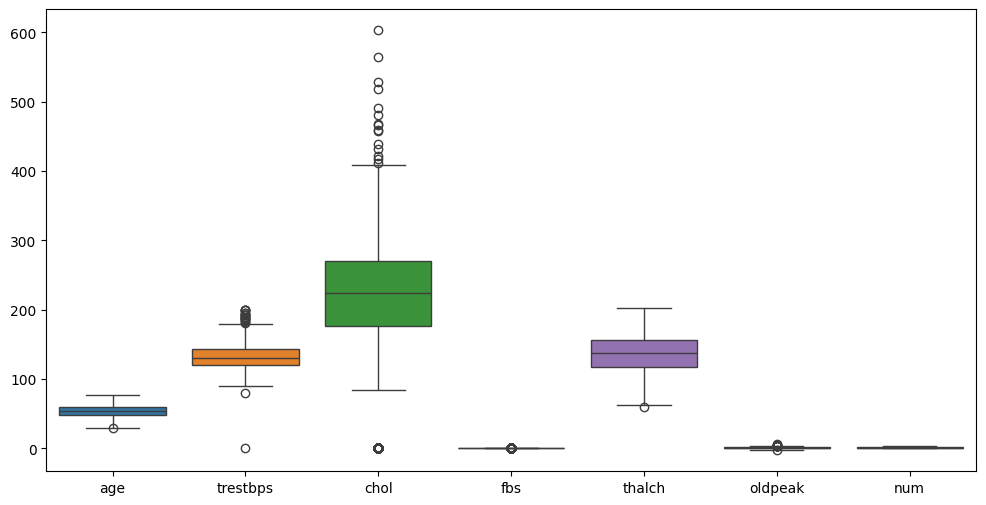

In [11]:
#Box Plots
plt.figure(figsize=(12,6))
sns.boxplot(data=df)
plt.show()

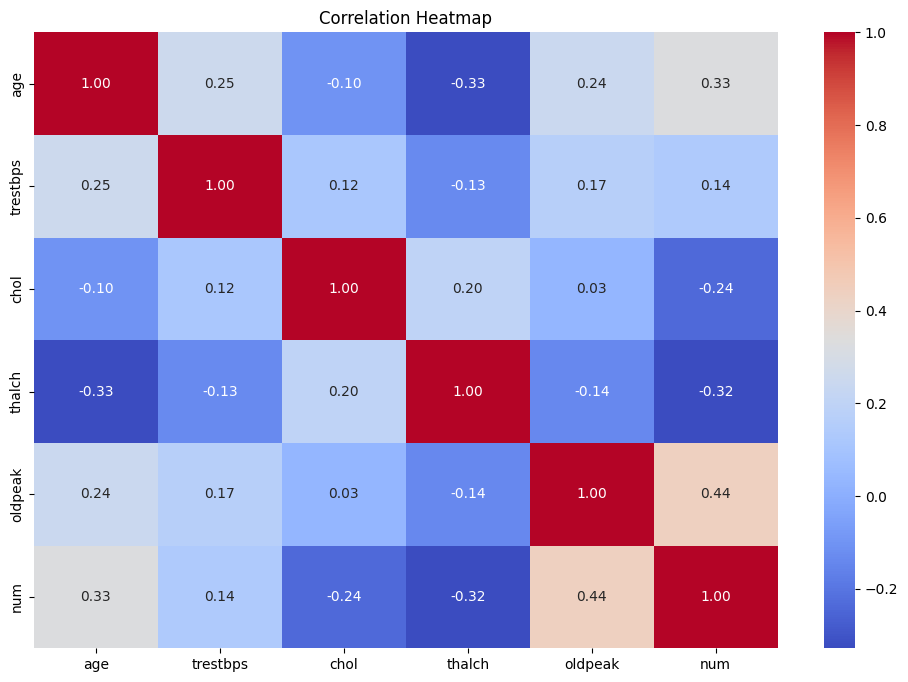

In [12]:
#correlation matrices.
plt.figure(figsize=(12,8))
sns.heatmap(df[["age", "trestbps", "chol", "thalch", "oldpeak", "num"]].corr(), annot=True, cmap='coolwarm', fmt=".2f")
plt.title("Correlation Heatmap")
plt.show()

In [ ]:
# Feature Engineering:

In [13]:
#encoding categorical variables
cat_col = df.select_dtypes(include=['object']).columns

df[cat_col] = df[cat_col].astype(str)

le = LabelEncoder()
for col in cat_col:
    df[col] = le.fit_transform(df[col])

df

,age,sex,cp,trestbps,chol,fbs,restecg,thalch,exang,oldpeak,slope,thal,num
0,63,1,3,145,233,True,0,150,1,2.3,0,0,0
1,41,1,1,135,203,False,1,132,1,0.0,1,0,0
2,57,1,0,140,192,False,1,148,1,0.4,1,0,0
3,52,1,3,118,186,False,0,190,1,0.0,1,0,0
4,57,1,0,110,201,False,1,126,3,1.5,1,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
903,53,1,0,125,0,False,1,120,1,1.5,2,1,4
904,62,1,0,166,170,False,2,120,3,3.0,1,2,4
905,56,1,2,170,0,False,0,123,3,2.5,0,2,4
906,56,1,2,144,208,True,2,105,2,NaN,0,2,4


In [15]:
#scaling numerical features
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()

num_col = df[["age","sex", "cp", "trestbps", "chol", "fbs", "restecg", "thalch", "exang", "oldpeak", "slope", "thal"]]
df[["age","sex", "cp", "trestbps", "chol", "fbs", "restecg", "thalch", "exang", "oldpeak", "slope", "thal"]] = scaler.fit_transform(df[["age","sex", "cp", "trestbps", "chol", "fbs", "restecg", "thalch", "exang", "oldpeak", "slope", "thal"]])

df

,age,sex,cp,trestbps,chol,fbs,restecg,thalch,exang,oldpeak,slope,thal,num
0,1.006027,0.514416,2.320276,0.567394,0.281297,1.976894,-1.561352,0.524183,-0.774285,1.288612,-1.672770,-1.553454,0
1,-1.397560,0.514416,0.232258,0.076967,0.013526,-0.505844,0.013879,-0.147705,-0.774285,-0.815249,-0.224843,-1.553454,0
2,0.350503,0.514416,-0.811752,0.322181,-0.084656,-0.505844,0.013879,0.449529,-0.774285,-0.449360,-0.224843,-1.553454,0
3,-0.195767,0.514416,2.320276,-0.756760,-0.138211,-0.505844,-1.561352,2.017268,-0.774285,-0.815249,-0.224843,-1.553454,0
4,0.350503,0.514416,-0.811752,-1.149102,-0.004325,-0.505844,0.013879,-0.371668,1.260594,0.556834,-0.224843,-1.553454,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
903,-0.086513,0.514416,-0.811752,-0.413461,-1.798388,-0.505844,0.013879,-0.595631,-0.774285,0.556834,1.223083,-0.251020,4
904,0.896773,0.514416,-0.811752,1.597292,-0.281021,-0.505844,1.589110,-0.595631,1.260594,1.928917,-0.224843,1.051414,4
905,0.241249,0.514416,1.276267,1.793463,-1.798388,-0.505844,-1.561352,-0.483649,1.260594,1.471556,-1.672770,1.051414,4
906,0.241249,0.514416,1.276267,0.518352,0.058155,1.976894,1.589110,-1.155538,0.243155,NaN,-1.672770,1.051414,4


In [16]:
#handling missing values
df.isnull().sum()

,0
age,0
sex,0
cp,0
trestbps,0
chol,0
fbs,0
restecg,0
thalch,0
exang,0
oldpeak,62


In [18]:
df['oldpeak'].fillna(df['oldpeak'].median(), inplace=True)
df.isnull().sum()

/tmp/ipython-input-2830706356.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['oldpeak'].fillna(df['oldpeak'].median(), inplace=True)


,0
age,0
sex,0
cp,0
trestbps,0
chol,0
fbs,0
restecg,0
thalch,0
exang,0
oldpeak,0


In [19]:
#Desicion Tree Classification

In [20]:
#Split the dataset into training and testing sets (e.g., using an 80-20 split).
from sklearn.model_selection import train_test_split

X = df.drop('num', axis=1)
y = df['num']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
X_test

,age,sex,cp,trestbps,chol,fbs,restecg,thalch,exang,oldpeak,slope,thal
865,1.006027,0.514416,1.276267,-0.168247,-1.798388,-0.505844,1.589110,-0.931575,1.260594,-0.815249,-0.224843,1.051414
439,0.459757,0.514416,-0.811752,1.793463,-1.798388,1.976894,1.589110,-1.155538,1.260594,-0.815249,-1.672770,-0.251020
342,-1.397560,0.514416,0.232258,-0.658674,0.798987,-0.505844,1.589110,0.897454,-0.774285,-0.815249,-1.672770,1.051414
736,0.787519,0.514416,-0.811752,0.616437,0.352702,-0.505844,0.013879,0.449529,1.260594,1.928917,-1.672770,1.051414
785,0.022741,0.514416,-0.811752,-1.149102,0.040303,-0.505844,-1.561352,-1.043556,1.260594,-0.815249,-0.224843,-0.251020
...,...,...,...,...,...,...,...,...,...,...,...,...
580,-0.195767,0.514416,-0.811752,0.322181,0.575844,-0.505844,0.013879,-0.073051,1.260594,1.014195,-0.224843,-0.251020
868,1.224535,0.514416,-0.811752,-0.364418,0.986426,-0.505844,-1.561352,0.748146,-1.791724,-0.357888,-1.672770,1.051414
445,-0.086513,0.514416,-0.811752,0.322181,0.013526,1.976894,-1.561352,0.710819,1.260594,2.020390,-1.672770,1.051414
786,0.022741,0.514416,-0.811752,-0.560589,0.754358,-0.505844,-1.561352,-0.744939,1.260594,2.111862,-0.224843,-0.251020


In [21]:
#Implement a Decision Tree Classification model using a library like scikit-learn.
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, f1_score, recall_score, precision_score, classification_report, confusion_matrix
model = DecisionTreeClassifier()

In [22]:
#Train the model on the training set and evaluate its performance on the testing set using appropriate evaluation metrics
#(e.g., accuracy, precision, recall, F1-score, ROC-AUC).

model.fit(X_train, y_train)
y_pred_train = model.predict(X_train)
y_pred_test = model.predict(X_test)

accuracy_score_train = accuracy_score(y_train, y_pred_train)
accuracy_score_test = accuracy_score(y_test, y_pred_test)

precision_score_train = precision_score(y_train, y_pred_train, average='weighted')
precision_score_test = precision_score(y_test, y_pred_test, average='weighted')

recall_score_train = recall_score(y_train, y_pred_train, average='weighted')
recall_score_test = recall_score(y_test, y_pred_test, average='weighted')

f1_score_train = f1_score(y_train, y_pred_train, average='weighted')
f1_score_test = f1_score(y_test, y_pred_test, average='weighted')

print("accuracy_score_train:",accuracy_score_train)
print("accuracy_score_test:",accuracy_score_test)
print("precision_score_train:",precision_score_train)
print("precision_score_test:",precision_score_test)
print("recall_score_train:",recall_score_train)
print("recall_score_test:",recall_score_test)
print("f1_score_train:",f1_score_train)
print("f1_score_test:",f1_score_test)

accuracy_score_train: 1.0
accuracy_score_test: 0.521978021978022
precision_score_train: 1.0
precision_score_test: 0.5202945202945203
recall_score_train: 1.0
recall_score_test: 0.521978021978022
f1_score_train: 1.0
f1_score_test: 0.5204325399533918


In [23]:
#Perform hyperparameter tuning to optimize the Decision Tree model.
#Experiment with different hyperparameters such as maximum depth, minimum samples split, and criterion.

from sklearn.model_selection import GridSearchCV

param_grid = {
    'criterion': ['gini', 'entropy'],
    'max_depth': [3, 4, 5, 6,8, 10, None] ,
    'min_samples_split': [5, 7, 10, 15],
    'min_samples_leaf': [4, 6, 8, 10]
}



model_para = DecisionTreeClassifier()

grid_search = GridSearchCV(estimator=model_para, param_grid=param_grid, cv=5, scoring='accuracy')

grid_search.fit(X_train, y_train)

print("Best hyperparameters:", grid_search.best_params_)
print("Best score:", grid_search.best_score_)

best_model = grid_search.best_estimator_
y_pred_test_best = best_model.predict(X_test)
test_accuracy_best = accuracy_score(y_test, y_pred_test_best)
print("Test accuracy of best model:", test_accuracy_best)

Best hyperparameters: {'criterion': 'entropy', 'max_depth': 6, 'min_samples_leaf': 8, 'min_samples_split': 7}
Best score: 0.5439962210675484
Test accuracy of best model: 0.5439560439560439


Accuracy: 0.5439560439560439

Classification Report:
               precision    recall  f1-score   support

           0       0.69      0.88      0.77        89
           1       0.37      0.40      0.38        48
           2       0.20      0.05      0.07        22
           3       0.08      0.06      0.07        17
           4       0.00      0.00      0.00         6

    accuracy                           0.54       182
   macro avg       0.27      0.28      0.26       182
weighted avg       0.47      0.54      0.49       182


Confusion Matrix:



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


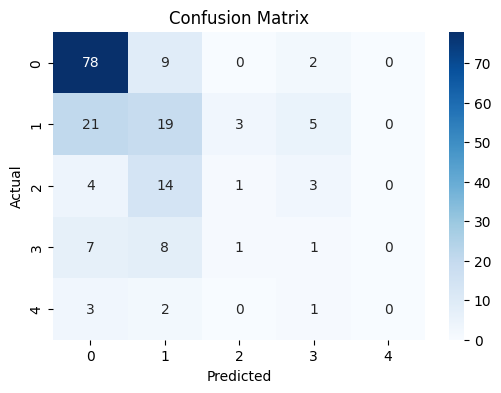

In [24]:
#Analyse the performance of the Decision Tree model using the evaluation metrics obtained.
y_pred = best_model.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))
print("\nConfusion Matrix:\n")

plt.figure(figsize=(6,4))
sns.heatmap(confusion_matrix(y_test, y_pred), annot=True, fmt='d', cmap='Blues')
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

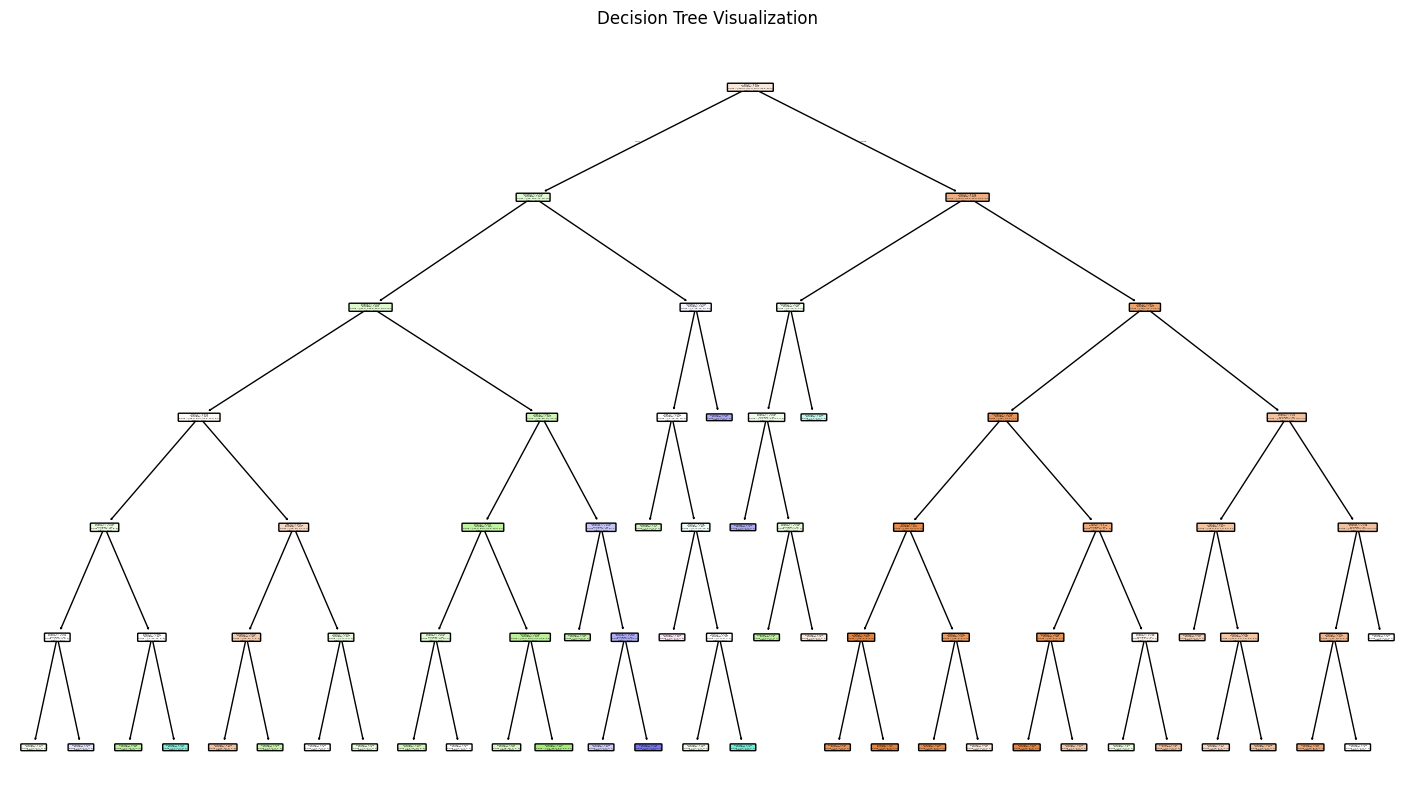

In [25]:
#Visualize the decision tree structure to understand the rules learned by the model and identify important features
from sklearn.tree import plot_tree
plt.figure(figsize=(18,10))
plot_tree(best_model, filled=True, feature_names=X.columns, class_names=True, rounded=True)
plt.title("Decision Tree Visualization")
plt.show()

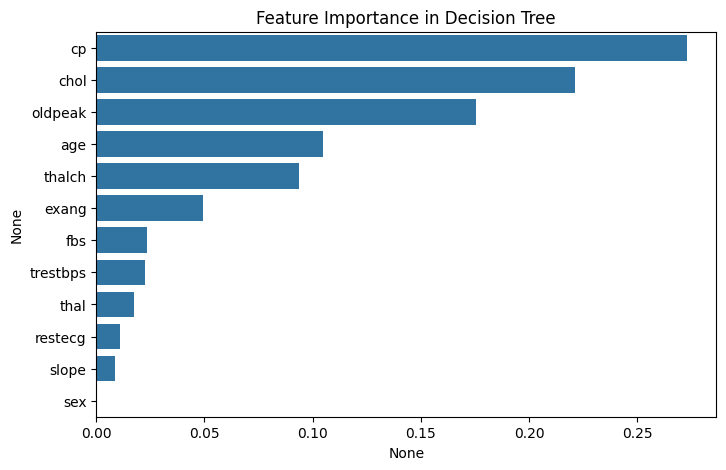

In [26]:
#identify important features
feature_importances = pd.Series(best_model.feature_importances_, index=X.columns).sort_values(ascending=False)
plt.figure(figsize=(8,5))
sns.barplot(x=feature_importances, y=feature_importances.index)
plt.title("Feature Importance in Decision Tree")
plt.show()

In [27]:
# Interview Questions:

In [28]:
#1. What are some common hyperparameters of decision tree models, and how do they affect the model's performance?
# Ans:- max_depth- limits the depth of the tree to prevents overfitiing
#       min_samples_splits- minimun samples requried to split a node and higher value make the mdoel simple
#       min_samples_leaf- minimun samples requried at a leaf node to controls tree
#       criterion- measures the quality of a split
#       max_features- limits the numbber of features considered for splitting

In [29]:
#2. What is the difference between the Label encoding and One-hot encoding?
#Ans:- Label Encoding- converts each category into a unique integer and it is used for the ordinal data
#      Hot Encoding- creates a new binary column for each category and it is used for the nominal data